# DBSCAN Clustering

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time  # Added for execution time tracking

In [2]:
# Load the dataset
X = pd.read_csv('finalclusteringdataset.csv')
start_time = time.time()  # Start timing

In [3]:
# Train–Test Split (for evaluation only, clustering is fit on full data)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(X, test_size=0.2, random_state=42)
X_train = train_df[['trip_frequency','average_booking_value','destination_diversity','session_duration','search_behavior']]
X_test = test_df[['trip_frequency','average_booking_value','destination_diversity','session_duration','search_behavior']]
# Do not save train/test to CSV; use only as variables

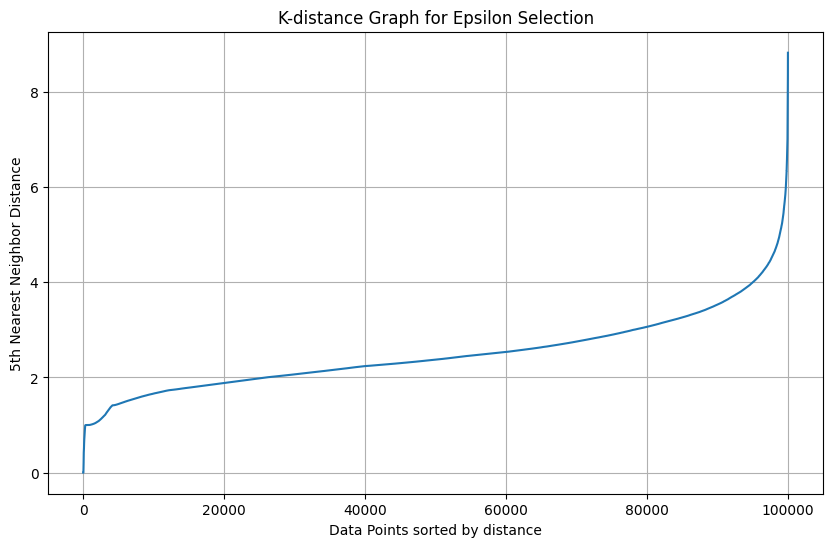

In [4]:
# Find optimal epsilon using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-distance Graph for Epsilon Selection')
plt.grid(True)
plt.show()

In [5]:
# AUTOMATIC EPSILON SELECTION - using percentile method
eps_min = distances[int(len(distances)*0.95)]
eps_max = distances[int(len(distances)*0.99)]
eps_auto = (eps_min + eps_max) / 2  # Take midpoint

print(f'Suggested epsilon range: {eps_min:.4f} to {eps_max:.4f}')
print(f'Auto-selected epsilon: {eps_auto:.4f}')

Suggested epsilon range: 3.9949 to 5.1111
Auto-selected epsilon: 4.5530


In [6]:
# Apply DBSCAN with AUTO epsilon
min_samples = 5  # Adjust if needed
dbscan = DBSCAN(eps=eps_auto, min_samples=min_samples, algorithm='auto')
cluster_labels = dbscan.fit_predict(X)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

In [7]:
# Evaluate clustering (only if we have at least 2 clusters and not all noise)
if n_clusters > 1 and n_noise < len(X):
    mask = cluster_labels != -1
    if mask.sum() > 0:
        sample_idx = np.random.choice(mask.sum(), size=min(10000, mask.sum()), replace=False)
        sil_score = silhouette_score(X[mask].iloc[sample_idx], cluster_labels[mask][sample_idx])
        db_score = davies_bouldin_score(X[mask], cluster_labels[mask])
    else:
        sil_score = None
        db_score = None
else:
    sil_score = None
    db_score = None

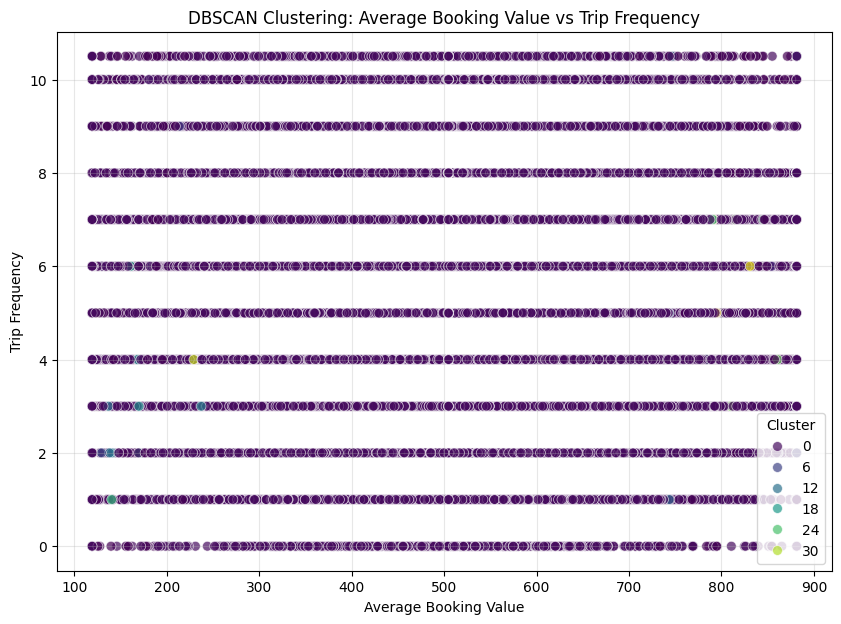

In [8]:
# Cluster Scatter Plot: Average_Booking_Value vs Trip_Frequency
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X.assign(Cluster=cluster_labels),
                x='average_booking_value', y='trip_frequency',
                hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('DBSCAN Clustering: Average Booking Value vs Trip Frequency')
plt.xlabel('Average Booking Value')
plt.ylabel('Trip Frequency')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Cluster distribution
unique, counts = np.unique(cluster_labels, return_counts=True)

In [10]:
# Calculate metrics before saving
end_time = time.time()
execution_time = end_time - start_time
# Print summary metrics
print(f'Number of Clusters: {n_clusters}')
if sil_score is not None:
    print(f'Silhouette Score: {sil_score:.4f}')
    print(f'Davies-Bouldin Score: {db_score:.4f}')
else:
    print('Silhouette Score: N/A')
    print('Davies-Bouldin Score: N/A')
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f'Noise Points: {count} samples ({count/len(X)*100:.2f}%)')
    else:
        print(f'Cluster {cluster}: {count} samples ({count/len(X)*100:.2f}%)')
print(f'Execution Time: {execution_time:.2f} seconds')
# Save results
X['Cluster'] = cluster_labels
X.to_csv('dbscan_results.csv', index=False)

Number of Clusters: 35
Silhouette Score: -0.0202
Davies-Bouldin Score: 0.6243
Noise Points: 750 samples (0.75%)
Cluster 0: 98893 samples (98.89%)
Cluster 1: 14 samples (0.01%)
Cluster 2: 14 samples (0.01%)
Cluster 3: 7 samples (0.01%)
Cluster 4: 8 samples (0.01%)
Cluster 5: 29 samples (0.03%)
Cluster 6: 47 samples (0.05%)
Cluster 7: 10 samples (0.01%)
Cluster 8: 13 samples (0.01%)
Cluster 9: 12 samples (0.01%)
Cluster 10: 42 samples (0.04%)
Cluster 11: 15 samples (0.01%)
Cluster 12: 14 samples (0.01%)
Cluster 13: 10 samples (0.01%)
Cluster 14: 7 samples (0.01%)
Cluster 15: 4 samples (0.00%)
Cluster 16: 9 samples (0.01%)
Cluster 17: 12 samples (0.01%)
Cluster 18: 5 samples (0.00%)
Cluster 19: 8 samples (0.01%)
Cluster 20: 5 samples (0.00%)
Cluster 21: 5 samples (0.00%)
Cluster 22: 6 samples (0.01%)
Cluster 23: 6 samples (0.01%)
Cluster 24: 5 samples (0.00%)
Cluster 25: 5 samples (0.00%)
Cluster 26: 5 samples (0.00%)
Cluster 27: 8 samples (0.01%)
Cluster 28: 5 samples (0.00%)
Cluster 29:

In [11]:
# Silhouette Score Comparison — Train vs Test
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Use the clusterer fitted on the full dataset to predict on train/test
train_labels = dbscan.fit_predict(X_train)
test_labels = dbscan.fit_predict(X_test)

# Remove noise points for silhouette calculation
train_mask = train_labels != -1
test_mask = test_labels != -1

train_score = silhouette_score(X_train[train_mask], train_labels[train_mask]) if train_mask.sum() > 1 else float('nan')
test_score = silhouette_score(X_test[test_mask], test_labels[test_mask]) if test_mask.sum() > 1 else float('nan')

scores = [train_score, test_score]
types = ['Train', 'Test']
plt.figure(figsize=(6,4))
bars = plt.bar(types, scores, color=['skyblue', 'salmon'])
plt.title('Silhouette Score Comparison — Train vs Test')
plt.ylabel('Silhouette Score')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{score:.2f}', ha='center', va='bottom')
plt.show()

MemoryError: Unable to allocate 1.00 GiB for an array with shape (1696, 79125) and data type float64